<a href="https://colab.research.google.com/github/SpringBoardMentor193s/SentinelNet_Oct_Batch/blob/ganesh/modeltraining_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import pandas as pd

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)
df.head()



Saving kdd_train (1).csv to kdd_train (1).csv


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [3]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

pipeline = Pipeline(steps=[('preprocessor', preprocess)])
processed_data = pipeline.fit_transform(df)

processed_data


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5164893 stored elements and shape (125973, 145)>

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop('labels', axis=1)
y = df['labels']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


numeric_cols_X = X_train.select_dtypes(include=['int64','float64']).columns
categorical_cols_X = X_train.select_dtypes(include=['object']).columns


preprocess_fixed = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols_X),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_X)
    ],
    remainder='passthrough'
X_train_processed = preprocess_fixed.fit_transform(X_train)
X_test_processed = preprocess_fixed.transform(X_test)

model = RandomForestClassifier()
model.fit(X_train_processed, y_train)

RandomForestClassifier()

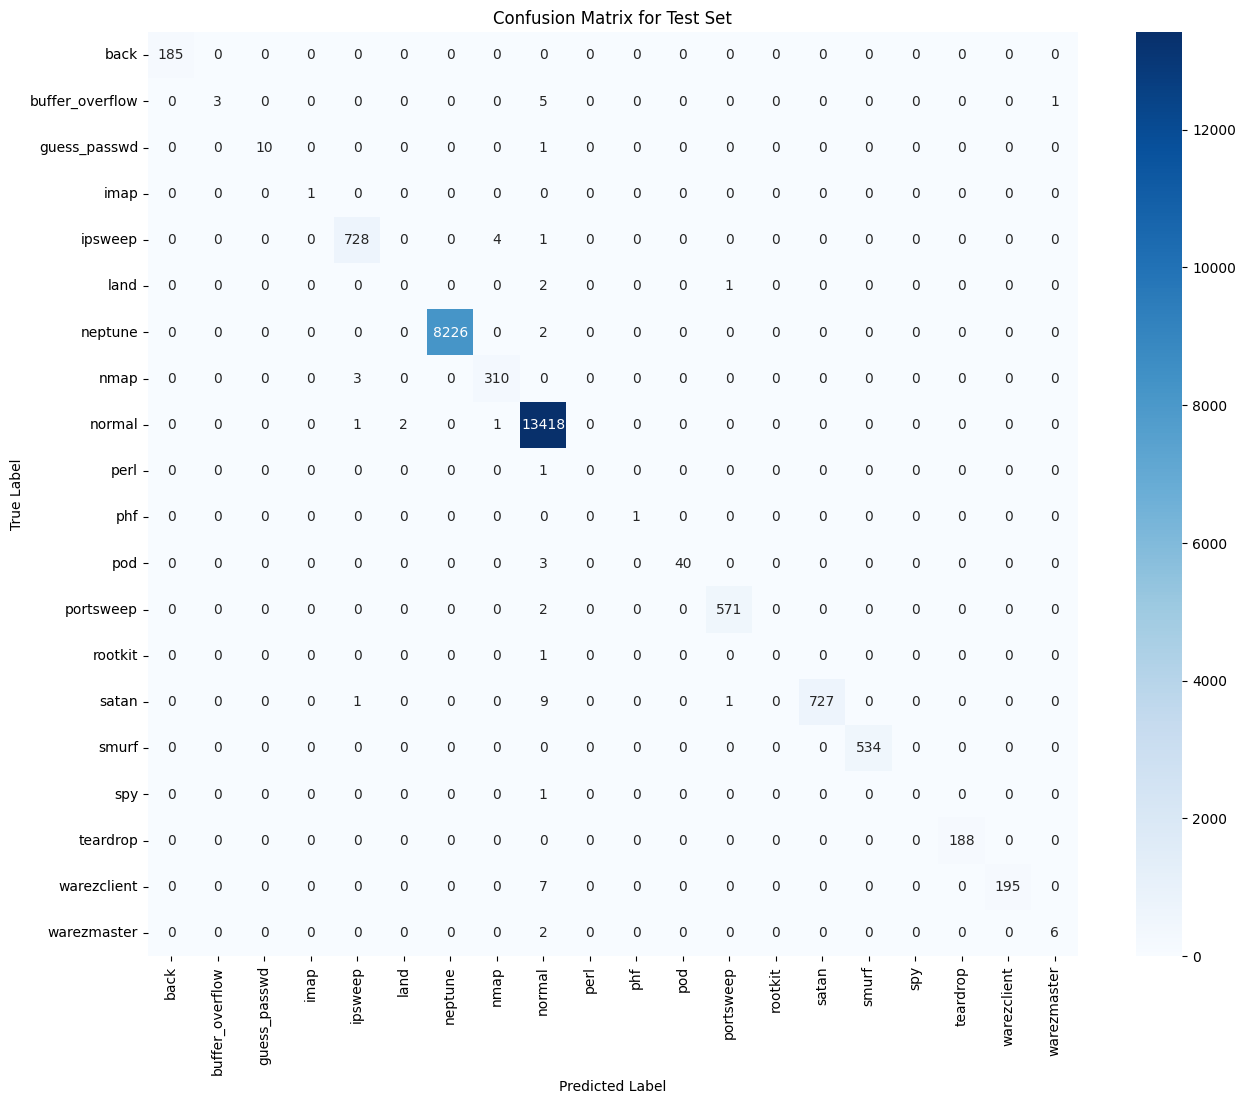

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_test, y_pred)


labels = sorted(y_test.unique())

plt.figure(figsize=(15, 12))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Test Set')
plt.show()

In [9]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test_processed)

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
                 precision    recall  f1-score   support

           back       1.00      1.00      1.00       185
buffer_overflow       1.00      0.33      0.50         9
   guess_passwd       1.00      0.91      0.95        11
           imap       1.00      1.00      1.00         1
        ipsweep       0.99      0.99      0.99       733
           land       0.00      0.00      0.00         3
        neptune       1.00      1.00      1.00      8228
           nmap       0.98      0.99      0.99       313
         normal       1.00      1.00      1.00     13422
           perl       0.00      0.00      0.00         1
            phf       1.00      1.00      1.00         1
            pod       1.00      0.93      0.96        43
      portsweep       1.00      1.00      1.00       573
        rootkit       0.00      0.00      0.00         1
          satan       1.00      0.99      0.99       738
          smurf       1.00      1.00      1.00       534
       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [8]:
numeric_feature_names = list(numeric_cols_X)
categorical_transformer = preprocess_fixed.named_transformers_['cat']
categorical_feature_names = list(categorical_transformer.get_feature_names_out(categorical_cols_X))


all_feature_names = numeric_feature_names + categorical_feature_names

print("Number of features after preprocessing:", len(all_feature_names))
print("Feature names after preprocessing:")
for name in all_feature_names:
    print(name)

Number of features after preprocessing: 122
Feature names after preprocessing:
duration
src_bytes
dst_bytes
land
wrong_fragment
urgent
hot
num_failed_logins
logged_in
num_compromised
root_shell
su_attempted
num_root
num_file_creations
num_shells
num_access_files
num_outbound_cmds
is_host_login
is_guest_login
count
srv_count
serror_rate
srv_serror_rate
rerror_rate
srv_rerror_rate
same_srv_rate
diff_srv_rate
srv_diff_host_rate
dst_host_count
dst_host_srv_count
dst_host_same_srv_rate
dst_host_diff_srv_rate
dst_host_same_src_port_rate
dst_host_srv_diff_host_rate
dst_host_serror_rate
dst_host_srv_serror_rate
dst_host_rerror_rate
dst_host_srv_rerror_rate
protocol_type_icmp
protocol_type_tcp
protocol_type_udp
service_IRC
service_X11
service_Z39_50
service_aol
service_auth
service_bgp
service_courier
service_csnet_ns
service_ctf
service_daytime
service_discard
service_domain
service_domain_u
service_echo
service_eco_i
service_ecr_i
service_efs
service_exec
service_finger
service_ftp
service_ft

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier


param_grid = {
    'n_estimators': [50, 100, 200],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}


rf_model_for_tuning = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_model_for_tuning,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=2
)


print("Starting GridSearchCV fit...")
grid_search.fit(X_train_processed, y_train)
print("GridSearchCV fit complete.")


best_model = grid_search.best_estimator_


print("Best parameters found by GridSearchCV:", grid_search.best_params_)


print("Hyperparameter tuning with GridSearchCV is complete.")

Starting GridSearchCV fit...
Fitting 3 folds for each of 96 candidates, totalling 288 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


**Reasoning**:
The previous execution resulted in a UserWarning because some classes in `y_train` had fewer samples than the `cv` folds, making stratification impossible for those classes. To avoid this warning while still performing cross-validation, I will explicitly use `KFold` with `shuffle=True` instead of `StratifiedKFold` (which is the default for classification in `GridSearchCV`). `KFold` does not attempt stratification, thus avoiding the warning.



In [ ]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestClassifier


param_grid = {
    'n_estimators': [50, 100, 200],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}


rf_model_for_tuning = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_model_for_tuning,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=KFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=2
)


print("Starting GridSearchCV fit...")
grid_search.fit(X_train_processed, y_train)
print("GridSearchCV fit complete.")


best_model = grid_search.best_estimator_


print("Best parameters found by GridSearchCV:", grid_search.best_params_)


print("Hyperparameter tuning with GridSearchCV is complete.")